[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-biology/AdvancesMSDataProcessing/blob/master/SpectralDataPreprocessingTreatment/matchms_networking.ipynb)


> **Source:** [github.com](https://github.com/matchms/matchms)


## Importing fragmentation data (MS/MS)

The _matchms_ library can import MS/MS data in various formats, such as .mzml, .mzxml, or GNPS-style .mgf files. Another option would be to use the Universal Spectrum Identifier for mass spectra [_Universal Spectrum Identifier for mass spectra_](https://www.biorxiv.org/content/10.1101/2020.12.07.415539v1.full).
Let's start with some GNPS spectra in .mgf file format that can be obtained [here](https://external.gnps2.org/gnpslibrary). For the following example, we have downloaded this spectral library.

In [ ]:
!pip install matchms matchmsextras

Use the mgf file from [Nature Protocols volume 21, pages 1265–1299 (2026)](https://www.nature.com/articles/s41596-025-01237-6).

In [ ]:
import requests

url_to_mgf = 'https://gnps2.org/resultfile?task=19e2a7f29df248518b13c5ded5dd3bcd&file=nf_output/clustering/specs_ms.mgf'

In [ ]:
mgf_content = requests.get(url_to_mgf).text
with open('specs_ms.mgf', 'w') as f:
    f.write(mgf_content)

Calculate spectrum similarities: Modified Cosine Score [Watrous et al. (PNAS, 2012)](https://www.pnas.org/content/109/26/E1743).

In [ ]:
from matchms.importing import load_from_mgf

spectra = list(load_from_mgf("specs_ms.mgf"))

/usr/local/lib/python3.13/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


In [ ]:
len(spectra)

398

In [ ]:
spectra[0].metadata

{'feature_id': '1',
 'scans': '1',
 'charge': 1,
 'retention_time': 2035.505,
 'ms_level': '2',
 'precursor_mz': 568.2995}

In [ ]:
#%%timeit
from matchms.similarity import ModifiedCosineGreedy
from matchms import calculate_scores

similarity_measure = ModifiedCosineGreedy(tolerance=0.005)
scores = calculate_scores(spectra, spectra, similarity_measure,
                          is_symmetric=True)

Calculating similarities: 100%|██████████| 398/398 [00:14<00:00, 27.01it/s] 


In [ ]:
import networkx as nx
import matchmsextras.networking as net
from matchms.networking import SimilarityNetwork

ms_network = SimilarityNetwork(identifier_key="feature_id",
                               score_cutoff=0.7,
                               max_links=10)
ms_network.create_network(scores, score_name = "ModifiedCosineGreedy_score")
our_network = ms_network.graph

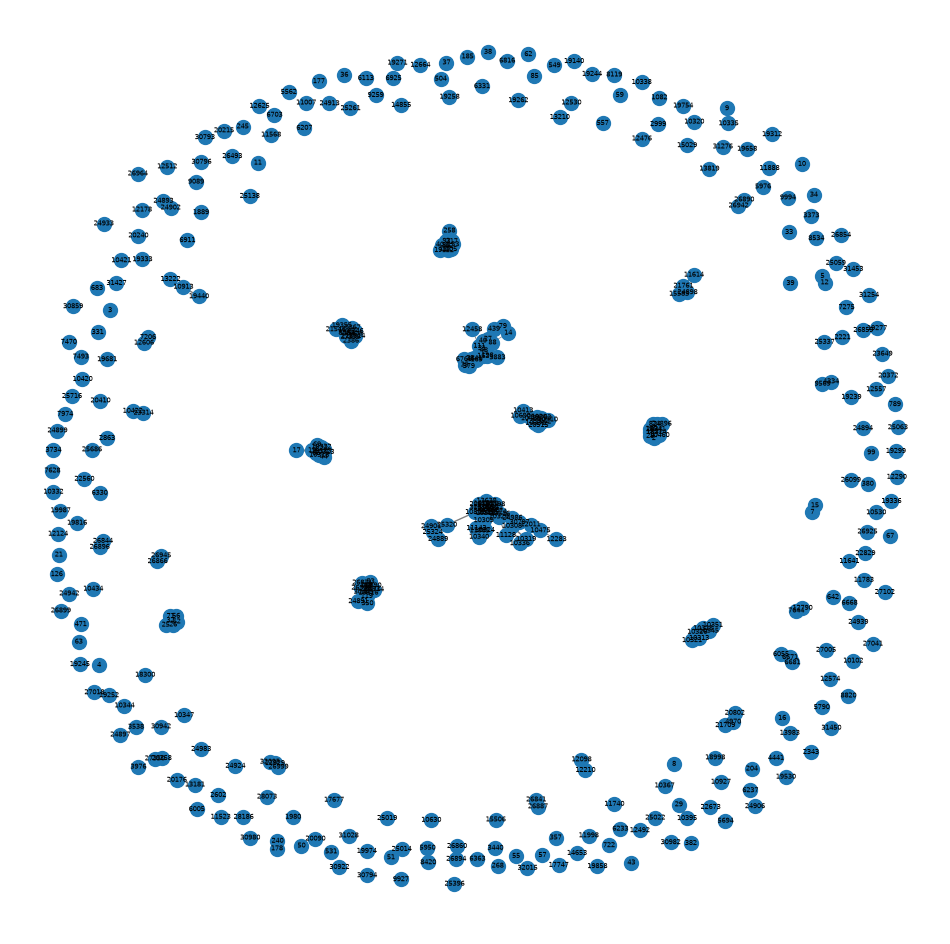

In [ ]:
net.plot_cluster(our_network)

In [ ]:
subnetworks = [our_network.subgraph(c).copy() for c in nx.connected_components(our_network)]

In [ ]:
target_node = '10308'

clusters = {}
for i, subnet in enumerate(subnetworks):
    if len(subnet.nodes) > 2: # exclude clusters with <=2 nodes
        if target_node in subnet.nodes:
            print(target_node, 'is in component:', i)
        clusters[i] = len(subnet.nodes)

clusters

10308 is in component: 3


{2: 13,
 3: 36,
 4: 11,
 7: 14,
 8: 19,
 9: 6,
 14: 6,
 30: 11,
 43: 3,
 48: 9,
 52: 11,
 53: 4,
 68: 3,
 79: 3}

In [ ]:
len(subnetworks[3].nodes())

36

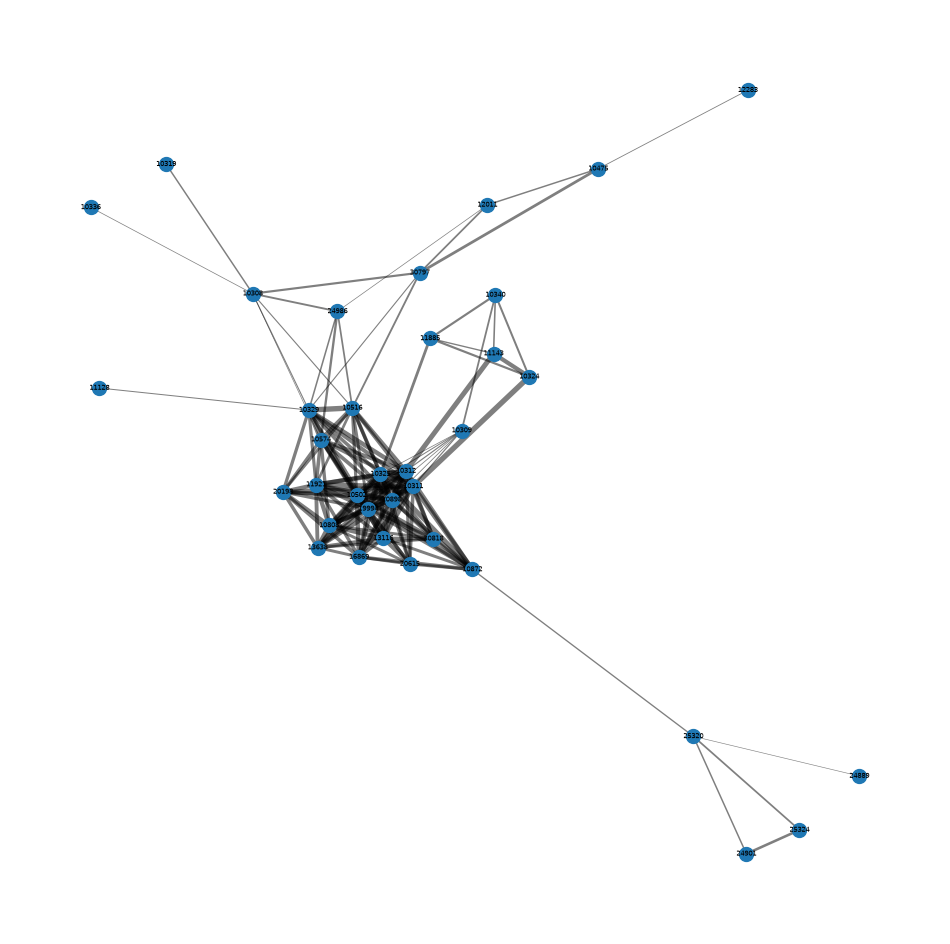

In [ ]:
net.plot_cluster(subnetworks[3])

<details>
<summary><b>Challenge 1: Try to use gemini to create a mirror plot betwenn nodes 10308 and 10309 from the subnetwork above</b></summary>

```python
from matchms.plotting.spectrum_plots import plot_spectra_mirror
import matplotlib.pyplot as plt

# Find spectra for nodes 10308 and 10309
spectrum_10308 = None
spectrum_10309 = None

for s in spectra:
    if s.metadata.get('feature_id') == '10308':
        spectrum_10308 = s
    if s.metadata.get('feature_id') == '10309':
        spectrum_10309 = s
    if spectrum_10308 and spectrum_10309:
        break

if spectrum_10308 and spectrum_10309:
    fig = plot_spectra_mirror(spectrum_10308, spectrum_10309)
    plt.title("Mirror Plot between Node 10308 and Node 10309")
    plt.xlabel("m/z")
    plt.ylabel("Intensity")
    plt.show()
else:
    print("Could not find one or both spectra for nodes 10308 and 10309.")
```

</details>

In [ ]:
nx.write_graphml(our_network, "network_GNPS_cutoff_07.graphml")